In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: False


/zhome/21/3/204026/miniforge3/envs/vdeftet/lib/python3.8/site-packages/tqdm-4.67.1-py3.8.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import sys
sys.path.append("/Users/mariepicquet/thesis/deftet-med")

In [4]:
import torch
print(torch.cuda.is_available())

from dataloader import create_dataloader

dl = create_dataloader(
    shapenet_source="/work3/s233736/datasets/shapenetcore",
    save_cache_root="/work3/s233736/deftet_runs/debug_run",
    train=False,
    batch_size=1,
    only_chairs=True,
)

batch = next(iter(dl))
print(batch["sample_points"].shape)
print(batch["sdf_value"].shape)

False
==> preprocess watertight mesh


Applying preprocessing: 100%|██████████| 2034/2034 [02:16<00:00, 14.95it/s]


==> preprocess point cloud


Applying preprocessing: 100%|██████████| 2034/2034 [00:28<00:00, 72.10it/s]


==> preprocess sdf


Applying preprocessing: 100%|██████████| 2034/2034 [00:37<00:00, 54.62it/s]


torch.Size([1, 100000, 3])
torch.Size([1, 100000])


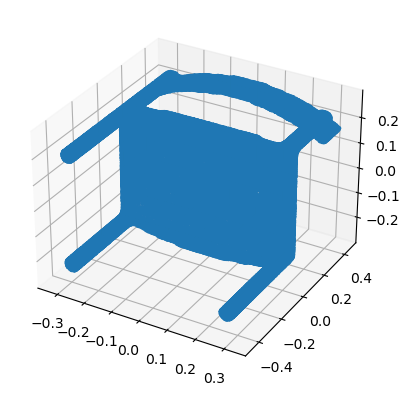

In [5]:
import matplotlib.pyplot as plt

points = batch["sample_points"][0].cpu().numpy()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)

plt.show()

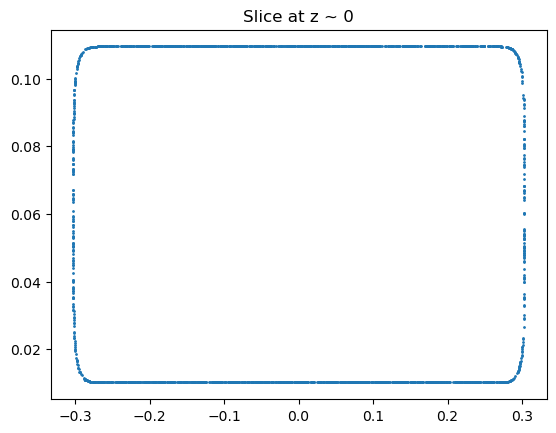

In [6]:
import numpy as np

# take a thin slice around z = 0
mask = np.abs(points[:, 2]) < 0.01
slice_pts = points[mask]

plt.scatter(slice_pts[:, 0], slice_pts[:, 1], s=1)
plt.title("Slice at z ~ 0")
plt.show()

In [1]:
import torch
print(torch.cuda.is_available())

from vox_dataloader import create_dataloader

dl = create_dataloader(
    mri_source="/work3/s233736/datasets/MRI",
    save_cache_root="/work3/s233736/deftet_runs/debug_run",
    train=False,
    batch_size=1,
    only_chairs=True,
)

batch = next(iter(dl))
print(batch["sample_points"].shape)
print(batch["sdf_value"].shape)

/zhome/21/3/204026/miniforge3/envs/vdeftet/lib/python3.8/site-packages/tqdm-4.67.1-py3.8.egg/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


False
create_dataloader source: /work3/s233736/datasets/MRI
dataset length: 1
first file: /work3/s233736/datasets/MRI/T1_bin.nii
==> preprocess sdf
torch.Size([1, 100000, 3])
torch.Size([1, 100000])


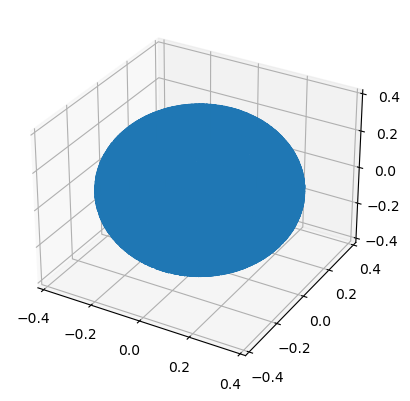

In [2]:
import matplotlib.pyplot as plt

points = batch["sample_points"][0].cpu().numpy()

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=1)

plt.show()

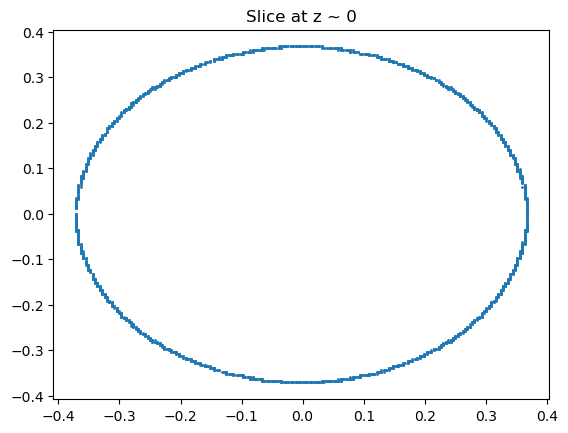

In [3]:
import numpy as np

# take a thin slice around z = 0
mask = np.abs(points[:, 2]) < 0.01
slice_pts = points[mask]

plt.scatter(slice_pts[:, 0], slice_pts[:, 1], s=1)
plt.title("Slice at z ~ 0")
plt.show()

In [4]:
shapenet_source='/work3/s233736/datasets/MRI'
save_cache_root = '/work3/s233736/deftet_runs/run_01'
from vox_dataloader import MRIVoxelDataset

In [5]:
print("create_dataloader source:", shapenet_source)
ds = MRIVoxelDataset(source=shapenet_source, train=False)
print("dataset length:", len(ds))
if len(ds) > 0:
    print("first file:", ds.paths[0])

create_dataloader source: /work3/s233736/datasets/MRI
dataset length: 1
first file: /work3/s233736/datasets/MRI/T1_bin.nii


In [6]:
import os


sv_dir = os.path.join(save_cache_root, 'watertight')
if not os.path.exists(sv_dir):
     os.makedirs(sv_dir)

In [14]:
from tqdm import tqdm

dataloader = create_dataloader(
    mri_source='/work3/s233736/datasets/MRI',
    train=False,
    batch_size=1
)

#cnt = 0
for data in tqdm(dataloader): # TODO WHAT ARE THESE BASHES 
    #name_list = data['name']
    print('sample_points:', data['sample_points'].shape) # [B, N_surface, 3]
    print('sdf_point:', data['sdf_point'].shape) # [B, N_sdf, 3]
    print('sdf_value:', data['sdf_value'].shape) # [B, N_sdf]
    print('name:', data['name']) # list[str]
    break

create_dataloader source: /work3/s233736/datasets/MRI
dataset length: 1
first file: /work3/s233736/datasets/MRI/T1_bin.nii
==> preprocess sdf





  0%|          | 0/1 [00:06<?, ?it/s]

sample_points: torch.Size([1, 100000, 3])
sdf_point: torch.Size([1, 100000, 3])
sdf_value: torch.Size([1, 100000])
name: ['T1_bin']
